In [2]:
%pip install jupysql pandas matplotlib duckdb-engine
import pandas as pd
import modules.build_geonames_db as build_geonames_db
import modules.geonames_db_search as geonames_db_search
from pathlib import Path
import time
from modules.utils import format_time
import matplotlib.pyplot as plt

if "conn" in globals():
    globals()["conn"].close() # Allow script rerunning

%load_ext sql
geonames_search = geonames_db_search.GeonamesSearch(topk=5, threshold=3)
conn = geonames_search.connection
%config SqlMagic.displaylimit = None
%sql conn --alias duckdb

/home/rpatroni/bzk-post-processing/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


/home/rpatroni/bzk-post-processing/.venv/lib/python3.12/site-packages/sql/parse.py:339: SyntaxWarning: invalid escape sequence '\:'
  Given a query, replaces all occurrences of ':variable' with '\:variable' and
/home/rpatroni/bzk-post-processing/.venv/lib/python3.12/site-packages/sql/parse.py:369: SyntaxWarning: invalid escape sequence '\:'
  Given a query, replaces all occurrences of 'example'[x:y] with 'example'[x\:y].


The 'toml' package isn't installed. To load settings from pyproject.toml or ~/.jupysql/config, install with: pip install toml

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

displaylimit: Value None will be treated as 0 (no limit)

In [3]:

print(f"DB Size: {Path(build_geonames_db.DUCK_DB_PATH).stat().st_size / 1e9:.2f} GB")
description = conn.execute("""DESCRIBE""").fetchdf()
description = description[['database', 'name', 'column_names', 'column_types']]
description.set_index(['database', 'name'], inplace=True)
description.insert(0, 'row_count', float('nan'))


for db_name, table_name in description.index:
    if table_name not in ["fullHierarchy", "allNames"]:
        row_count = conn.execute(f'SELECT COUNT(*) FROM {db_name}.{table_name}').fetchone()[0]
        description.loc[(db_name, table_name), 'row_count'] = row_count

display(description.style.format({'row_count': '{:_.0f}'}))

feature_codes = conn.execute(
    """
        SELECT feature_class, feature_code, COUNT(*) AS count
        FROM geonames
        GROUP BY feature_class, feature_code
        ORDER BY count DESC
""").fetchdf()
feature_codes['feature_code'] = feature_codes['feature_class'] + "." + feature_codes['feature_code']
feature_codes.drop(columns=['feature_class'], inplace=True)
feature_codes["proportion"] = feature_codes['count'] / feature_codes['count'].sum()
feature_codes = feature_codes.head(20)
try:
    build_geonames_db.download_file("https://download.geonames.org/export/dump/featureCodes_en.txt", Path("dumps/geonames/featureCodes_en.txt"))
    feature_codes = feature_codes.merge(
        pd.read_csv(
            "dumps/geonames/featureCodes_en.txt", 
            sep='\t', header=None, names=["feature_code", "designation", "description"]
    ), on='feature_code', how='left')
    feature_codes = feature_codes[['feature_code', 'designation', 'count', 'proportion']]
except Exception as e:
    print(f"Could not download feature code descriptions: {e}")
display(
    feature_codes.style
    .format({'count': '{:_.0f}', 'proportion': '{:.0%}'})
    .bar(subset=['proportion'], vmin=0, vmax=1)
)

DB Size: 1.88 GB


,feature_code,designation,count,proportion
0,P.PPL,populated place,4_685_832,35%
1,H.STM,stream,990_177,7%
2,T.HLL,hill,502_096,4%
3,T.MT,mountain,422_594,3%
4,S.FRM,farm,359_812,3%
5,H.LK,lake,309_547,2%
6,S.SCH,school,298_042,2%
7,H.STMI,intermittent stream,261_178,2%
8,S.CH,church,259_635,2%
9,S.HTL,hotel,241_608,2%


In [4]:
%%sql
SELECT COUNT(*) AS number_of_cities FROM geonames WHERE feature_class = 'P'

Running query in 'duckdb'

number_of_cities
5195947


5 195 947 populated places in geonames against [2 887 930](https://query.wikidata.org/#SELECT%20%28COUNT%28DISTINCT%20%3Fid%29%20AS%20%3Fcount%29%20WHERE%20%7B%0A%20%20%3Fid%20wdt%3AP31%20%2F%20wdt%3AP279%2a%20wd%3AQ123964505.%0A%7D) on wikidata

However there are [709 681](https://query.wikidata.org/#SELECT%20%28COUNT%28DISTINCT%20%3Fid%29%20AS%20%3Fcount%29%20WHERE%20%7B%0A%20%20%3Fid%20wdt%3AP31%20%2F%20wdt%3AP279%2a%20wd%3AQ123964505.%0A%20%20%3Fid%20wdt%3AP1566%20%3FsomeGeonamesId%0A%7D) wikidata populated places that don't link to a geoname.

Among which [13 554](https://query.wikidata.org/#SELECT%20%28COUNT%28DISTINCT%20%3Fid%29%20AS%20%3Fcount%29%20WHERE%20%7B%0A%20%20%3Fid%20wdt%3AP31%20%2F%20wdt%3AP279%2a%20wd%3AQ253019.%0A%20%20%3Fid%20wdt%3AP1566%20%3FsomeGeonamesId%0A%7D) are ["Ortsteil"](https://www.wikidata.org/wiki/Q253019) including [Sudberg](https://www.wikidata.org/wiki/Q2362997) in Wuppertal, which is present in bzk open but not [geonames](https://www.geonames.org/2805753/wuppertal.html) neither gnd.

In [5]:
%%sql
SELECT levenshtein(nfc_normalize(lower(alternateName)), nfc_normalize(lower('Sudberg'))) AS score, *
FROM allNames NATURAL LEFT JOIN simplifiedGeonames
WHERE score <= 2 AND feature_class = 'P'
ORDER BY score
LIMIT 10;

Running query in 'duckdb'

score,geonameId,isolanguage,alternateName,isPreferredName,isShortName,isColloquial,isHistoric,gndUri,name,asciiname,feature_class,feature_code,country_code,admin1_code,admin2_code,admin3_code,admin4_code,admin5_code,parentCityIds,parentRegionIds
1,11962460,se,Sundberg,True,None,None,None,None,Salmenkallio,Salmenkallio,P,PPLX,FI,01,011,091,None,None,None,None
1,2942109,None,Budberg,None,None,None,None,None,Budberg,Budberg,P,PPL,DE,07,051,05170,05170032,None,None,None
1,2942108,None,Budberg,None,None,None,None,None,Budberg,Budberg,P,PPL,DE,07,059,05974,05974052,None,None,None
1,2942108,None,Budberg,True,None,None,None,None,Budberg,Budberg,P,PPL,DE,07,059,05974,05974052,None,None,None
1,2658465,None,Suberg,True,None,None,None,None,Suberg,Suberg,P,PPL,CH,BE,243,303,None,None,None,None
1,5214588,None,Suedberg,True,None,None,None,None,Suedberg,Suedberg,P,PPL,US,PA,107,60464,None,None,None,None
1,11587121,de,Surberg,None,None,None,None,None,Surberg,Surberg,P,PPLL,CH,SG,1724,3275,None,None,None,None
1,2942109,None,Budberg,True,None,None,None,None,Budberg,Budberg,P,PPL,DE,07,051,05170,05170032,None,None,None
1,2658465,None,Suberg,None,None,None,None,None,Suberg,Suberg,P,PPL,CH,BE,243,303,None,None,None,None
1,11587121,None,Surberg,True,None,None,None,None,Surberg,Surberg,P,PPLL,CH,SG,1724,3275,None,None,None,None


In [6]:
csv_read_args = dict(keep_default_na=False, dtype=str, na_values=[""])

bzkopen_val = pd.read_csv("open_data/bzkopen_addresses_val.csv", **csv_read_args)
ESTIMATED_TOTAL_ADDRESSES = 4_228_682 # from compare.ipynb

In [7]:
print("Benchmark complete address search, using country restrictions...")
start_time = time.monotonic()
matches = geonames_search.link_parsed_addresses(bzkopen_val)
end_time = time.monotonic()
elapsed = end_time - start_time
print(f"Search took {format_time(elapsed)}\nEstimate time for {ESTIMATED_TOTAL_ADDRESSES:_} addresses: {format_time(((elapsed)/ len(bzkopen_val)) * ESTIMATED_TOTAL_ADDRESSES)}")
display(matches[matches["query"] == "Austr."].head())
display(matches[matches["query"] == "N.Y."].head())

Benchmark complete address search, using country restrictions...
Country hints set for 0 / 20 addresses for entity type Country
Starting search for entity type Country
Search for entity type Country took 0:00:05 and returned 72 matches
Country hints set for 20 countries
Country hints set for 0 / 5 addresses for entity type State
Starting search for entity type State
Search for entity type State took 0:00:01 and returned 5 matches
Country hints set for 0 / 17 addresses for entity type Region
Starting search for entity type Region
Search for entity type Region took 0:00:04 and returned 93 matches
Country hints set for 0 / 24 addresses for entity type District
Starting search for entity type District
Search for entity type District took 0:00:04 and returned 71 matches
Country hints set for 27 / 111 addresses for entity type City
Starting search for entity type City
Search for entity type City took 0:00:25 and returned 857 matches
Country hints set for 2 / 16 addresses for entity type Neig

query nfc_query clean_query  \
input_row entity_type entity_rank geonameId                                 
112       Country     1           2782113    Austr.    Austr.       austr   
                      2           2077456    Austr.    Austr.       austr   
                      3           453733     Austr.    Austr.       austr   
                                  8642971    Austr.    Austr.       austr   
                      5           3723988    Austr.    Austr.       austr   

                                            abbreviation_pattern nfc_alt_name  \
input_row entity_type entity_rank geonameId                                     
112       Country     1           2782113                 austr%      Austria   
                      2           2077456                 austr%    Australia   
                      3           453733                  austr%        Eesti   
                                  8642971                 austr%         Rush   
                      5           3723988                 austr%        Ayiti   

                                            clean_alt_name  raw_distance  \
input_row entity_type entity_rank geonameId                                
112       Country     1           2782113          austria             2   
                      2           2077456        australia             4   
                      3           453733             eesti             4   
                                  8642971             rush             4   
                      5           3723988            ayiti             4   

                                             cleaned_distance  \
input_row entity_type entity_rank geonameId                     
112       Country     1           2782113                   2   
                      2           2077456                   4   
                      3           453733                    3   
                                  8642971                   3   
                      5           3723988                   3   

                                             may_be_abbreviation isolanguage  \
input_row entity_type entity_rank geonameId                                    
112       Country     1           2782113                   True          en   
                      2           2077456                   True          en   
                      3           453733                   False          et   
                                  8642971                  False         NaN   
                      5           3723988                  False          ht   

                                             ... admin1_code  admin2_code  \
input_row entity_type entity_rank geonameId  ...                            
112       Country     1           2782113    ...          00         None   
                      2           2077456    ...          00         None   
                      3           453733     ...          00         None   
                                  8642971    ...           L         None   
                      5           3723988    ...          00         None   

                                             admin3_code  admin4_code  \
input_row entity_type entity_rank geonameId                             
112       Country     1           2782113           None         None   
                      2           2077456           None         None   
                      3           453733            None         None   
                                  8642971           None         None   
                      5           3723988           None         None   

                                             admin5_code parentCityIds  \
input_row entity_type entity_rank geonameId                              
112       Country     1           2782113           None          <NA>   
                      2           2077456           None          <NA>   
                      3           453733

query nfc_query clean_query  \
input_row entity_type entity_rank geonameId                               
58        State       1           5128638    N.Y.      N.Y.          ny   
147       City        1           5128581    N.Y.      N.Y.          ny   
                      2           2789986    N.Y.      N.Y.          ny   
149       State       1           5128638    N.Y.      N.Y.          ny   

                                            abbreviation_pattern nfc_alt_name  \
input_row entity_type entity_rank geonameId                                     
58        State       1           5128638                  n% y%           NY   
147       City        1           5128581                  n% y%           NY   
                      2           2789986                  n% y%           Ny   
149       State       1           5128638                  n% y%           NY   

                                            clean_alt_name  raw_distance  \
input_row entity_type entity_rank geonameId                                
58        State       1           5128638               ny             2   
147       City        1           5128581               ny             2   
                      2           2789986               ny             3   
149       State       1           5128638               ny             2   

                                             cleaned_distance  \
input_row entity_type entity_rank geonameId                     
58        State       1           5128638                   0   
147       City        1           5128581                   0   
                      2           2789986                   0   
149       State       1           5128638                   0   

                                             may_be_abbreviation isolanguage  \
input_row entity_type entity_rank geonameId                                    
58        State       1           5128638                  False        abbr   
147       City        1           5128581                  False        abbr   
                      2           2789986                  False         NaN   
149       State       1           5128638                  False        abbr   

                                             ... admin1_code  admin2_code  \
input_row entity_type entity_rank geonameId  ...                            
58        State       1           5128638    ...          NY         None   
147       City        1           5128581    ...          NY          NaN   
                      2           2789986    ...         WAL          WLX   
149       State       1           5128638    ...          NY         None   

                                             admin3_code  admin4_code  \
input_row entity_type entity_rank geonameId                             
58        State       1           5128638           None         None   
147       City        1           5128581            NaN          NaN   
                      2           2789986             83        83028   
149       State       1           5128638           None         None   

                                             admin5_code parentCityIds  \
input_row entity_type entity_rank geonameId                              
58        State       1           5128638           None          <NA>   
147       City        1           5128581           None          <NA>   
                      2           2789986           None          <NA>   
149       State       1           5128638           None          <NA>   

                                                                               parentRegionIds  \
input_row entity_type entity_rank geonameId                                                      
58        State       1           5128638    [12902582, 12746282, 11887749, 12212303, 12212...   
147       City        1           5128581                                           [12213808]   
                      2           2789

In [8]:
hierachically_grouped_matches = geonames_search.group_hierarchical_matches(matches)

NotImplementedError: 

In [ ]:
hierachically_grouped_matches.head(10)

group_rank       query  \
input_row group_id entity_type entity_rank geonameId                           
0         0        City        1           2849483             1  Regensburg   
1         0        City        1           2935517             1    Dortmund   
3         0        City        1           2894742             1   Jöhlingen   
          1        District    1           2934506             1     Durlach   
          2        District    1           6556258             1     Durlach   
          3        District    1           6557306             1     Durlach   
          4        Region      1           6455365             1       Baden   
          5        Region      1           6458813             1       Baden   
          6        Region      1           7285134             1       Baden   
          7        Region      1           7872834             1       Baden   

                                                       nfc_query clean_query  \
input_row group_id entity_type entity_rank geonameId                           
0         0        City        1           2849483    Regensburg  regensburg   
1         0        City        1           2935517      Dortmund    dortmund   
3         0        City        1           2894742     Jöhlingen   johlingen   
          1        District    1           2934506       Durlach     durlach   
          2        District    1           6556258       Durlach     durlach   
          3        District    1           6557306       Durlach     durlach   
          4        Region      1           6455365         Baden       baden   
          5        Region      1           6458813         Baden       baden   
          6        Region      1           7285134         Baden       baden   
          7        Region      1           7872834         Baden       baden   

                                                     abbreviation_pattern  \
input_row group_id entity_type entity_rank geonameId                        
0         0        City        1           2849483                   <NA>   
1         0        City        1           2935517                   <NA>   
3         0        City        1           2894742                   <NA>   
          1        District    1           2934506                   <NA>   
          2        District    1           6556258                   <NA>   
          3        District    1           6557306                   <NA>   
          4        Region      1           6455365                   <NA>   
          5        Region      1           6458813                   <NA>   
          6        Region      1           7285134                   <NA>   
          7        Region      1           7872834                   <NA>   

                                                     nfc_alt_name  \
input_row group_id entity_type entity_rank geonameId                
0         0        City        1           2849483     Regensburg   
1         0        City        1           2935517       Dortmund   
3         0        City        1           2894742      Jöhlingen   
          1        District    1           2934506        Durbach   
          2        District    1           6556258        Hurlach   
          3        District    1           6557306         Durach   
          4        Region      1           6455365          Baden   
          5        Region      1           6458813          Baden   
          6        Region      1           7285134          Baden   
          7        Region      1           7872834          Baden   

                                                     clean_alt_name  \
input_row group_id entity_type entity_rank geonameId                  
0         0        City        1           2849483       regensburg   
1         0        City        1           2935517         dortmund   
3         0        City        1           2894742        johlingen   
          1        Dist

In [ ]:
conn.execute("""
SELECT geonameId, geonames.name, population, geonames.feature_class, geonames.feature_code, geonames.admin1_code
FROM candidate_names LEFT JOIN geonames USING (geonameId)
WHERE geonames.country_code = 'BR' AND geonames.feature_class = 'P' AND clean_alt_name = 'sao paulo' AND isPreferredName
GROUP BY ALL
ORDER BY population DESC NULLS LAST
""").fetchdf()

,geonameId,name,population,feature_class,feature_code,admin1_code
0,3448439,São Paulo,12400232,P,PPLA,27
1,3388254,São Paulo,0,P,PPL,06
2,3388253,São Paulo,0,P,PPL,04
3,3388252,São Paulo,0,P,PPL,22
4,3448440,São Paulo,0,P,PPL,08
5,12555201,São Paulo,0,P,PPL,22
6,3388250,São Paulo,0,P,PPL,31
7,3662257,São Paulo,0,P,PPL,04
8,3388243,São Paulo,0,P,PPL,30
9,3448442,São Paulo,0,P,PPL,05


In [ ]:
ambiguous_addresses = hierachically_grouped_matches[hierachically_grouped_matches["group_rank"] == 1].groupby("input_row").filter(lambda x: len(x) > 1)
n_ambiguous_addresses = len(ambiguous_addresses.index.get_level_values("input_row").unique())
print(f"Number of ambiguous addresses: {n_ambiguous_addresses:_} ({n_ambiguous_addresses / len(bzkopen_val):.2%})")


Number of ambiguous addresses: 78 (51.32%)


,search_time
entity_type,
City,0:00:00.108776
Country,0:00:00.092284
District,0:00:00.089105
Neighborhood,0:00:00.088128
Region,0:00:00.108153
State,0:00:00.036225


,search_time
abbreviation_pattern,
False,0:00:00.130844
True,0:00:00.094453


<Axes: title={'center': 'Search Time by Query Length'}, xlabel='query'>

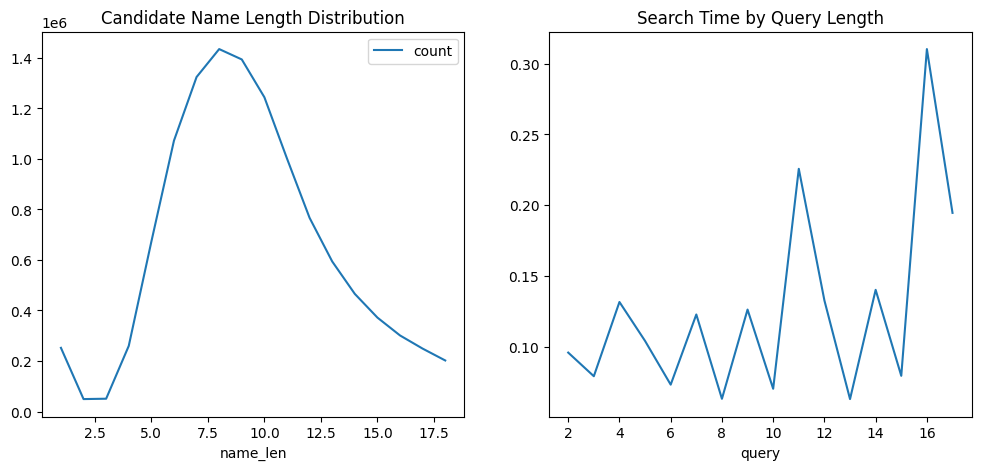

In [ ]:
import matplotlib.pyplot as plt
display(matches.groupby("entity_type")["search_time"].mean().apply(lambda x: format_time(x, round_to_seconds=False)).to_frame())
display(matches.groupby(matches["abbreviation_pattern"].isna())["search_time"].mean().apply(lambda x: format_time(x, round_to_seconds=False)).to_frame())
fig, axes = plt.subplots(1,2, figsize=(12, 5))
conn.execute("""
        SELECT len(clean_alt_name) AS name_len, COUNT(clean_alt_name) AS count 
        FROM candidate_names 
        WHERE clean_alt_name IS NOT NULL AND feature_class IN ('A', 'P', 'L')
        GROUP BY name_len
        HAVING name_len <= 18
        ORDER BY name_len
    """).fetchdf().plot(title="Candidate Name Length Distribution", x='name_len', y='count', kind='line', ax=axes[0])
matches.groupby(matches["query"].str.len())["search_time"].mean().plot(title="Search Time by Query Length", kind='line', ax=axes[1])

In [ ]:
conn.execute("""
        SELECT len(clean_alt_name) AS name_len, clean_alt_name, isolanguage, feature_class, feature_code, country_code, geonameid
        FROM candidate_names 
        WHERE clean_alt_name IS NOT NULL AND name_len >= 50 AND (feature_class IN ('A', 'P') OR feature_code LIKE 'RGN%')
    """).fetchdf().sample(10)

,name_len,clean_alt_name,isolanguage,feature_class,feature_code,country_code,geonameId
1591,65,uniao das freguesias de sao joao da pesqueira ...,NaN,A,ADM3,PT,12573660
1500,83,uniao das freguesias de cedofeita santo ildefo...,NaN,A,ADM3,PT,12573414
2722,50,fraccionamiento hacienda de las torres univers...,es,P,PPLX,MX,13293117
1093,52,ezequiel acevedo junior subdivision number 2 c...,NaN,P,PPL,US,4689752
3069,52,loma de las viboras santiago mexquititlan barr...,NaN,P,PPL,MX,8864701
563,61,pakistan counsil of scientific and industrial ...,NaN,P,PPLX,PK,11535006
1622,50,thuringer landgemeinde mohlsdorfteichwolframs...,NaN,A,ADM4,DE,8659001
2303,81,instituto del fondo nacional de la vivienda pa...,es,P,PPLX,MX,11371420
1651,50,municipality of sveta trojica v slovenskih gor...,en,A,ADM1,SI,8133590
2467,115,constitucion de mil ochocientos cincuenta y si...,NaN,P,PPLX,MX,11532149


In [ ]:
start_time = time.monotonic()
all_matches = []
for entity_type in geonames_db_search.EntityType:
    print(f"Benchmarking {entity_type.name} matches...")
    names = bzkopen_val[entity_type.name].dropna().unique()
    sub_start_time = time.monotonic()
    matches_ = geonames_search.link_entities(names, entity_type=entity_type)
    sub_end_time = time.monotonic()
    all_matches.extend(matches_)
    print(f"  {entity_type.name}: {len(matches_)} matches (took {format_time(sub_end_time - sub_start_time)})")
end_time = time.monotonic()
elapsed = end_time - start_time
print(f"Search took {format_time(elapsed)}\nEstimate time for {ESTIMATED_TOTAL_ADDRESSES:_} addresses: {format_time(((elapsed)/ len(bzkopen_val)) * ESTIMATED_TOTAL_ADDRESSES)}")
all_matches = pd.concat(all_matches, ignore_index=True)
display(all_matches[all_matches["query"] == "Austr."].head())
display(all_matches[all_matches["query"] == "N.Y."].head())

Benchmarking Country matches...
Query hits: defaultdict(<class 'int'>, {1: 12, 5: 8})
  Country: 20 matches (took 0:00:02)
Benchmarking State matches...
Query hits: defaultdict(<class 'int'>, {1: 4})
  State: 4 matches (took 0:00:00)
Benchmarking Region matches...
Query hits: defaultdict(<class 'int'>, {1: 8, 4: 9})
  Region: 17 matches (took 0:00:02)
Benchmarking District matches...
Query hits: defaultdict(<class 'int'>, {4: 3, 1: 20, 5: 1})
  District: 24 matches (took 0:00:02)
Benchmarking City matches...
Query hits: defaultdict(<class 'int'>, {1: 90, 4: 10, 5: 8})
  City: 108 matches (took 0:00:10)
Benchmarking Neighborhood matches...
Query hits: defaultdict(<class 'int'>, {4: 2, 1: 12, 5: 2})
  Neighborhood: 16 matches (took 0:00:02)
Search took 0:00:17
Estimate time for 4_228_682 addresses: 5 days, 13:49:46


,query,nfc_query,clean_query,country_restriction,abbreviation_pattern,nfc_alt_name,clean_alt_name,raw_distance,cleaned_distance,may_be_abbreviation,...,admin2_code,admin3_code,admin4_code,admin5_code,parentCityIds,parentRegionIds,Country,entity_type_map,entity_rank,search_time
31,Austr.,Austr.,austr,<NA>,austr%,Austria,austria,2,2,True,...,None,None,None,None,<NA>,"[12718413, 12503661, 9408659, 12217848]",Austria,"{'Country': True, 'State': False, 'Region': Fa...",1,0.078899
32,Austr.,Austr.,austr,<NA>,austr%,Australia,australia,4,4,True,...,None,None,None,None,<NA>,"[12626210, 7729898, 12217089]",Australia,"{'Country': True, 'State': False, 'Region': Fa...",2,0.078899
33,Austr.,Austr.,austr,<NA>,austr%,Eesti,eesti,4,3,False,...,None,None,None,None,<NA>,"[12718413, 12503661, 7729883, 12217933, 12217934]",Estonia,"{'Country': True, 'State': False, 'Region': Fa...",3,0.078899
34,Austr.,Austr.,austr,<NA>,austr%,Rush,rush,4,3,False,...,None,None,None,None,<NA>,<NA>,Ireland,"{'Country': True, 'State': False, 'Region': Fa...",3,0.078899
35,Austr.,Austr.,austr,<NA>,austr%,Cssr,cssr,4,3,False,...,None,None,None,None,<NA>,<NA>,Serbia and Montenegro,"{'Country': True, 'State': False, 'Region': Fa...",5,0.078899


,query,nfc_query,clean_query,country_restriction,abbreviation_pattern,nfc_alt_name,clean_alt_name,raw_distance,cleaned_distance,may_be_abbreviation,...,admin2_code,admin3_code,admin4_code,admin5_code,parentCityIds,parentRegionIds,Country,entity_type_map,entity_rank,search_time
72,N.Y.,N.Y.,ny,<NA>,n% y%,NY,ny,2,0,False,...,None,None,None,None,<NA>,"[12902582, 12746282, 11887749, 12212303, 12212...",United States,"{'Country': False, 'State': True, 'Region': Tr...",1,0.077376
855,N.Y.,N.Y.,ny,<NA>,n% y%,NY,ny,2,0,False,...,NaN,NaN,NaN,None,<NA>,[12213808],United States,"{'Country': False, 'State': False, 'Region': F...",1,0.025545
856,N.Y.,N.Y.,ny,<NA>,n% y%,Ny,ny,3,0,False,...,WLX,83,83028,None,<NA>,<NA>,Belgium,"{'Country': False, 'State': False, 'Region': F...",2,0.025545


In [ ]:
query = geonames_db_search.build_closest_matches_query(entity_type=geonames_db_search.EntityType["District"], topk=10, threshold=3)
query = query.replace("$1", "'Sinsheim'")
query = query.replace("$2", "NULL")
query = query.replace("$3", "NULL")
conn.execute(query).fetchdf()

,query,nfc_query,clean_query,country_restriction,abbreviation_pattern,nfc_alt_name,clean_alt_name,raw_distance,cleaned_distance,may_be_abbreviation,...,admin1_code,admin2_code,admin3_code,admin4_code,admin5_code,parentCityIds,parentRegionIds,Country,entity_type_map,entity_rank
0,Sinsheim,Sinsheim,sinsheim,<NA>,<NA>,Sinsheim,sinsheim,0,0,False,...,01,082,08226,08226085,None,<NA>,[2847614],Germany,"{'Country': False, 'State': False, 'Region': T...",1
1,Sinsheim,Sinsheim,sinsheim,<NA>,<NA>,Sinzheim,sinzheim,1,1,False,...,01,082,08216,08216049,None,<NA>,[3220725],Germany,"{'Country': False, 'State': False, 'Region': T...",2
2,Sinsheim,Sinsheim,sinsheim,<NA>,<NA>,Insheim,insheim,2,1,False,...,08,00,07337,07337044,None,<NA>,[2825001],Germany,"{'Country': False, 'State': False, 'Region': T...",3
3,Sinsheim,Sinsheim,sinsheim,<NA>,<NA>,Biesheim,biesheim,2,2,False,...,44,68,682,68036,None,<NA>,[3024296],France,"{'Country': False, 'State': False, 'Region': T...",4
4,Sinsheim,Sinsheim,sinsheim,<NA>,<NA>,Dingsheim,dingsheim,2,2,False,...,44,67,674,67097,None,<NA>,[2975587],France,"{'Country': False, 'State': False, 'Region': T...",4
5,Sinsheim,Sinsheim,sinsheim,<NA>,<NA>,Hipsheim,hipsheim,2,2,False,...,44,67,675,67200,None,<NA>,[2975232],France,"{'Country': False, 'State': False, 'Region': T...",4
6,Sinsheim,Sinsheim,sinsheim,<NA>,<NA>,Spiesheim,spiesheim,2,2,False,...,08,00,07331,07331061,None,<NA>,[2956708],Germany,"{'Country': False, 'State': False, 'Region': T...",4
7,Sinsheim,Sinsheim,sinsheim,<NA>,<NA>,Senheim,senheim,2,2,False,...,08,00,07135,07135079,None,<NA>,[3247464],Germany,"{'Country': False, 'State': False, 'Region': T...",4
8,Sinsheim,Sinsheim,sinsheim,<NA>,<NA>,Lipsheim,lipsheim,2,2,False,...,44,67,678,67268,None,<NA>,[2973781],France,"{'Country': False, 'State': False, 'Region': T...",4
9,Sinsheim,Sinsheim,sinsheim,<NA>,<NA>,Weinsheim,weinsheim,2,2,False,...,08,00,07232,07232226,None,<NA>,[3247913],Germany,"{'Country': False, 'State': False, 'Region': T...",4


In [ ]:
conn.execute("""
    SELECT min(levenshtein(alternateName, 'Sinsheim')) AS distance, argmin(alternateName, levenshtein(alternateName, 'Sinsheim')) AS name, geonameid, feature_class, feature_code
    FROM candidate_names
    WHERE entity_type_map['District']
    GROUP BY ALL
    HAVING distance <= 3
    ORDER BY distance ASC
    LIMIT 5
""").fetch_df()

,distance,name,geonameId,feature_class,feature_code
0,0,Sinsheim,6558063,A,ADM4
1,1,Sinzheim,6555635,A,ADM4
2,2,Ensheim,6554839,A,ADM4
3,2,Hipsheim,6441149,A,ADM4
4,2,Sontheim,6555572,A,ADM4


In [ ]:
%%sql
SELECT * FROM allNames WHERE geonameId = 2267057;

Running query in 'duckdb'

geonameId,isolanguage,alternateName,isPreferredName,isShortName,isColloquial,isHistoric,gndUri
2267057,fi,Lissabon,None,None,None,None,None
2267057,unlc,PTLIS,None,None,None,None,None
2267057,af,Lissabon,None,None,None,None,None
2267057,it,Lisbona,None,None,None,None,None
2267057,hu,Lisszabon,None,None,None,None,None
2267057,la,Lisbonum,None,None,None,None,None
2267057,None,Olyssiponis,False,None,None,None,https://d-nb.info/gnd/4035919-0
2267057,nds,Lissabon,None,None,None,None,None
2267057,co,Lisbona,None,None,None,None,None
2267057,mh,Lisbon,None,None,None,None,None


In [ ]:
%%sql
SELECT levenshtein(nfc_normalize(lower(alternateName)), nfc_normalize(lower('N.Y.'))) AS distance, (CASE WHEN alternateName SIMILAR TO 'Austr\w+' THEN 0 ELSE distance END) AS score, *
FROM allNames NATURAL LEFT JOIN simplifiedGeonames
WHERE (score <= 2) AND feature_class = 'A'
ORDER BY score
LIMIT 10;

Running query in 'duckdb'

distance,score,geonameId,isolanguage,alternateName,isPreferredName,isShortName,isColloquial,isHistoric,gndUri,name,asciiname,feature_class,feature_code,country_code,admin1_code,admin2_code,admin3_code,admin4_code,admin5_code,parentCityIds,parentRegionIds
7,0,2782113,ig,Austria,True,None,None,None,None,Republic of Austria,Republic of Austria,A,PCLI,AT,00,None,None,None,None,None,"[12718413, 12503661, 9408659, 12217848]"
8,0,2782113,bs,Austrija,True,None,None,None,None,Republic of Austria,Republic of Austria,A,PCLI,AT,00,None,None,None,None,None,"[12718413, 12503661, 9408659, 12217848]"
8,0,2782113,lt,Austrija,True,None,None,None,None,Republic of Austria,Republic of Austria,A,PCLI,AT,00,None,None,None,None,None,"[12718413, 12503661, 9408659, 12217848]"
7,0,2782113,et,Austria,True,None,None,None,None,Republic of Austria,Republic of Austria,A,PCLI,AT,00,None,None,None,None,None,"[12718413, 12503661, 9408659, 12217848]"
7,0,2782113,it,Austria,True,None,None,None,None,Republic of Austria,Republic of Austria,A,PCLI,AT,00,None,None,None,None,None,"[12718413, 12503661, 9408659, 12217848]"
6,0,2782113,None,Austrya,False,None,None,None,https://d-nb.info/gnd/4043271-3,Republic of Austria,Republic of Austria,A,PCLI,AT,00,None,None,None,None,None,"[12718413, 12503661, 9408659, 12217848]"
7,0,2782113,None,Austrja,False,None,None,None,https://d-nb.info/gnd/4043271-3,Republic of Austria,Republic of Austria,A,PCLI,AT,00,None,None,None,None,None,"[12718413, 12503661, 9408659, 12217848]"
9,0,3162270,None,Austrheim,True,None,None,None,None,Austrheim,Austrheim,A,ADM2,NO,46,4632,None,None,None,None,[12110600]
7,0,2782113,ki,Austria,True,None,None,None,None,Republic of Austria,Republic of Austria,A,PCLI,AT,00,None,None,None,None,None,"[12718413, 12503661, 9408659, 12217848]"
8,0,2782113,hr,Austrija,True,None,None,None,None,Republic of Austria,Republic of Austria,A,PCLI,AT,00,None,None,None,None,None,"[12718413, 12503661, 9408659, 12217848]"


In [ ]:
%%sql
SELECT parent.name AS parentName, parentId, child.name as childName, childId 
FROM hierarchy 
    JOIN geonames AS parent ON (hierarchy.parentId = parent.geonameId)
    JOIN geonames AS child ON (hierarchy.childId = child.geonameId)
WHERE 
    parent.country_code = child.country_code IS NOT TRUE AND
    parent.admin1_code = child.admin1_code IS NOT TRUE AND
    parent.admin2_code = child.admin2_code IS NOT TRUE AND
    parent.admin3_code = child.admin3_code IS NOT TRUE AND
    parent.admin4_code = child.admin4_code IS NOT TRUE AND
    parent.admin5_code = child.admin5_code IS NOT TRUE AND
    hierarchy.type = 'ADM'
LIMIT 10;

Running query in 'duckdb'

parentName,parentId,childName,childId
Earth,6295630,Africa,6255146
Earth,6295630,Asia,6255147
Earth,6295630,Europe,6255148
Earth,6295630,North America,6255149
Earth,6295630,South America,6255150
Earth,6295630,Oceania,6255151
Earth,6295630,Antarctica,6255152
Europe,6255148,Kingdom of Norway,3144096
Africa,6255146,Republic of Zambia,895949
Africa,6255146,Republic of Zimbabwe,878675


In [ ]:
%%sql
WITH 
geonames1 AS (
    SELECT * 
    FROM geonames
    WHERE geonames.geonameId IN (7117596, 5844411)
),
adm2 AS (
    SELECT geonames.*
    FROM geonames 
        RIGHT JOIN geonames1 USING (country_code, admin1_code, admin2_code) 
    WHERE 
        geonames.feature_class = 'A' AND 
        geonames.feature_code IN ('ADM2', 'ADM2H')
),
adm1 AS (
    SELECT geonames.*
    FROM geonames 
        RIGHT JOIN geonames1 USING (country_code, admin1_code) 
    WHERE 
        geonames.feature_class = 'A' AND 
        geonames.feature_code IN ('ADM1', 'ADM1H')
),
country AS (
    SELECT geonames.* 
    FROM geonames 
        JOIN countryInfo ON (geonames.geonameId = countryInfo.geonameid) 
        JOIN geonames1 USING (country_code)
)
SELECT * FROM geonames1 
UNION 
SELECT * FROM adm2
UNION
SELECT * FROM adm1
UNION
SELECT * FROM country

Running query in 'duckdb'

geonameId,name,asciiname,alternatenames,latitude,longitude,feature_class,feature_code,country_code,cc2,admin1_code,admin2_code,admin3_code,admin4_code,admin5_code,population,elevation,dem,timezone,modification_date
5844411,Annette Island Reserve,Annette Island Reserve,"Annette Island Indian Reservation,Annette Island Reserve",55.12839889526367,-131.4965362548828,A,ADMD,US,None,AK,198,None,None,None,5559,63,97,America/Metlakatla,2017-05-25
5879092,Alaska,Alaska,"'Alaka,AK,Alaeksa,Alakskak,Alaksu,Alasca,Alaschka,Alaska,Alaska suyu,Alaskaa,Alasko,Alaszka,Aleska,Aliaksa,Aliaska,Aljask,Aljaska,Aljaska shtaty,Aljaskae,Aljaske,Aljaška,Alyaska,Alyaska Shitati,Alâska,Alýaska,Anian,Aļaska,Ałasca,Estado de Alaska,Gamaland,Hakʼaz Dineʼé Bikéyah,I-Alaskha,Land of the Midnight Sun,New Albion,Sewards Folly,State of Alaska,Territory of Alaska,a la si jia,a la si jia zhou,alasaka,alaska,allaeseuka ju,allaeseukaju,arasuka zhou,yalaska,Àláskà,Αλάσκα,Аласка,Аляск,Аляскæ,Аляска,Аляска штаты,Аляске,Алјаска,Аљаска,Ալասքա,Ալյասկա,אלאסקע,אלסקה,آلاسکا,ألاسكا,ئالاسکا,الاسكا,الاسکا,الاسڪا,ܐܠܐܣܟܐ,अलास्का,अलास्‍का,আলাস্কা,ਅਲਾਸਕਾ,અલાસ્કા,ଆଲାସ୍କା,அலாஸ்கா,అలాస్కా,ಅಲಾಸ್ಕ,അലാസ്ക,ඇලස්කාව,รัฐอะแลสกา,အလက်စကာပြည်နယ်,ალასკა,አላስካ,ᎠᎳᏍᎦ,ᐊᓛᓯᑲ,ᱟᱞᱟᱥᱠᱟ,‘Ālaka,ⴰⵍⴰⵙⴽⴰ,アラスカ州,阿拉斯加,阿拉斯加州,ꯑꯂꯥꯁꯀꯥ,알래스카 주,알래스카주,𐌰𐌻𐌰𐍃𐌺𐌰",64.00028228759766,-150.00027465820312,A,ADM1,US,None,AK,None,None,None,None,740133,421,425,America/Anchorage,2025-04-12
7117568,Hoonah-Angoon Census Area,Hoonah-Angoon Census Area,Hoonah-Angoon,57.94807052612305,-134.9415283203125,A,ADM2,US,None,AK,105,None,None,None,2365,307,395,America/Juneau,2024-11-02
6252001,United States,United States,"'Amelika,A.S,ABD,ABS,ABŞ,ACSH,AISH,AKSH,ALeaa-Oko ti Amerika,AMN,ANU,AQSH,AS,Amelika,America,Amerika,Amerika Birlesik Devletleri,Amerika Birleşik Devletleri,Amerika Sarikat,Amerikan Yhdysvallat,Amerikas Foerenta Stater,Amerikas Forenede Stater,Amerikas Förenta Stater,Amerikas Savienotas Valstis,Amerikas Savienotās Valstis,Amerikas forente stater,Amerikayi Miacʻeal Nahangner,Amerikayi Miacʻyal Nahangner,Ameriketako Estatu Batuak,Ameriki,Amurka,Amérika Sarikat,Amɛrika,Amẹrikà,Bandariki Nordur-Ameriku,Bandarikin,Bandaríki Norður-Ameríku,Bandaríkin,DYA,Dei amerikanske sambandsstatane,Dewleten Yekbuyi yen Amerikaye,Dewletên Yekbûyî yên Amerîkayê,Dowlaaji Dentuɗi Amerik,EUA,Estados Unidos,Estats Units,Estatu Batuak,Etaa Sini,Etats-Unis,Etazonia,Feriene Steaten,Forente stater,Hoa Ky,Hoa Kỳ,Hononga o Amerika,IM,IPA,JAV,Jungtines Amerikos Valstijos,Jungtines Valstijos,Jungtinės Amerikos Valstijos,Jungtinės Valstijos,Leta Zunze Ubumwe za Amerika,Maraykanka,Marekani,Miacʻeal Nahangner,Qo'shma Shtatlar,S.U.A.,SA,SAD,SAM,SASHH,SHBA,SSHA,SU,SUA,Sambandsstatane,Sjedinene Americke Drzave,Sjedinene Drzave,Sjedinjene Americke Drzave,Sjedinjene Američke Države,Soedinennye Shtaty,Spojene staty,Spojene staty americke,Spojené státy,Spojené státy americké,Spojené štáty,Spojené štáty americké,Spoluceni Stati Ameriki,Stadis Unids da l'America,Stadis Unids da l’America,Stany Zjednoczone,Statele Unite ale Americii,Stati Uniti,Statys Unys,Suedineni shhati,U.S.,U.S.A.,UDA,US,USA,USA nutome,United States,United States of America,Usono,VS,VSA,Vereenegt Staaten,Vereinigte Staaten,Vereinigten Staaten von Amerika,Verenigde Staten,Yhdysvallat,ZDA,Zdruzene drzave Amerike,Združene države Amerike,Zlucanya Staty Ameryki,Zluchanyja Shtaty,alawlayat almthdt alamrykyt,alwlayat almthdt alamrykyt,amerika,amryka,ashsh,ayalat mthdh,ayalat mthdh amryka,i'u esa,i-U.S,l-Istati Uniti,ma. yu.,mei guo,migug,mthdh ayalat,ps,sanyukta rajya amarika,sanyukta rajya amerika,sanyukta rajya:,shrath‡,wڵatە yەkgrtwwەkan,ya q sh,yu ʿesi,yu'es,yu.aisa.,yu.es,yu.es.,yu.esa.,yuktarastra,yuuaaatit,yuʿesi,yways,ywnayٹiڑ siٹyٹis,ÂLeaa-Ôko tî Amerika,États-Unis,ʻAmelika,ʼrh״b,ΗΠΑ,АИШ,АКШ,АНУ,АЦШ,АҚШ,Злучаныя Штаты,Злучаныя Штаты Амерыкі,ИМ,САД,САЩ,США,Соединенные Штаты,Сполучені Штати Америки,Съединени щати,Сједињене Америчке Државе,Сједињене Државе,ԱՄՆ,Ամերիկայի Միացեալ Նահանգներ,Ամերիկայի Միացյալ

In [ ]:
%%sql
SELECT COUNT(DISTINCT gnd.geonameId) FROM gndNames NATURAL JOIN gnd
WHERE NOT EXISTS (
    SELECT 1 FROM alternateNames
    WHERE alternateNames.alternateName = gndNames.name AND alternateNames.geonameId = gnd.geonameId
)
LIMIT 10;

Running query in 'duckdb'

count(DISTINCT gnd.geonameId)
45838


There are ADMD entities that are the only reference of admin1_code. For now, ignore.

In [ ]:
%%sql
SELECT country.Country, geonames.* FROM geonames 
    JOIN (
        SELECT child.country_code as country_code, ANY_VALUE(child.geonameId) AS chosen_one FROM geonames AS child
        WHERE 
            starts_with(child.feature_code, 'ADMD') AND 
            child.admin1_code IS NOT NULL AND NOT EXISTS(
                SELECT * FROM geonames AS parent 
                WHERE 
                    parent.country_code = child.country_code AND
                    parent.admin1_code = child.admin1_code AND 
                    starts_with(parent.feature_code, 'ADM1')
            )
        GROUP BY child.country_code
    ) ON chosen_one = geonames.geonameId
    JOIN countryInfo AS country ON geonames.country_code = country.ISO


Running query in 'duckdb'

Country,geonameId,name,asciiname,alternatenames,latitude,longitude,feature_class,feature_code,country_code,cc2,admin1_code,admin2_code,admin3_code,admin4_code,admin5_code,population,elevation,dem,timezone,modification_date
Iran,66873,Sanandaj,Sanandaj,"Sanandaj,Shahrestan-e Sanandaj,Shahrestān-e Sanandaj,sanandaj,shahristani sanandaj,سَنَندَج,شَهرِستانِ سَنَندَج",32.41667175292969,47.0,A,ADMD,IR,None,00,None,None,None,None,0,None,32,Asia/Tehran,2024-07-23
Iraq,6687112,Ostān-e Kūt,Ostan-e Kut,"astan kwt,استان کوت",32.899200439453125,46.32870101928711,A,ADMD,IQ,None,00,None,None,None,None,0,None,62,Asia/Baghdad,2008-02-09
Saudi Arabia,100258,Minţaqat al Muqāt‘ah ash Shamālīyah,Mintaqat al Muqat`ah ash Shamaliyah,"Al Muqata`ah ash Shamaliyah,Al Muqāţa‘ah ash Shamālīyah,Mintaqat al Muqat`ah ash Shamaliyah,Minţaqat al Muqāt‘ah ash Shamālīyah",28.0,36.5,A,ADMD,SA,None,00,None,None,None,None,0,None,1104,Asia/Riyadh,2012-01-16
Seychelles,448411,Outer Islands,Outer Islands,None,-7.5,52.0,A,ADMD,SC,None,00,None,None,None,None,1167,None,-9999,Indian/Mahe,2006-03-23
Ukraine,562153,Galicia,Galicia,"Gali,Galicia,Galicie,Galicio,Galicja,Galitsiya,Galitsya,Galitzia,Galizia,Galizien,Galícia,Halichina,glyzyh,gʼalyzyʻ,גאַליציע,גליציה",49.5,23.0,A,ADMDH,UA,PL,00,None,None,None,None,0,None,341,Europe/Kyiv,2023-09-17
Samoa,4034973,Tuamasaga West,Tuamasaga West,None,-13.833330154418945,-171.86666870117188,A,ADMD,WS,None,00,None,None,None,None,0,None,106,Pacific/Apia,1993-12-22
Botswana,443222,Bakwena Tribal Territory,Bakwena Tribal Territory,None,-24.583330154418945,25.799999237060547,A,ADMD,BW,None,00,None,None,None,None,0,None,1015,Africa/Gaborone,2000-10-04
Laos,1653832,Muang Phrabatphônsan,Muang Phrabatphonsan,"Muang Phrabatphonsan,Muang Phrabatphônsan,Phone Sanh",18.278850555419922,103.17266845703125,A,ADMD,LA,None,00,None,None,None,None,0,None,184,Asia/Vientiane,2020-06-10
Kyrgyzstan,1527185,Tonskiy Rayon,Tonskiy Rayon,None,42.0,77.0,A,ADMD,KG,None,00,None,None,None,None,0,None,2933,Asia/Bishkek,1994-01-25
Cambodia,1821590,Khêt Tônlé Sab,Khet Tonle Sab,"Brigade des Lacs,Khet Tonle Sab,Khet Tonle Sap,Khêt Tônlé Sab,Province des Lacs",13.0,104.0,A,ADMD,KH,None,00,None,None,None,None,0,None,4,Asia/Phnom_Penh,2020-06-10


There are places under multiple cities in the informal hierachy. For now, include all.

In [ ]:
%%sql
SELECT 
    childId AS childId,
    child.name AS childName,
    unnest(list(parentId)) AS parentId,
    unnest(list(parent.name)) AS parentName
FROM hierarchy
JOIN geonames AS parent ON hierarchy.parentId = parent.geonameId
JOIN geonames AS child ON hierarchy.childId = child.geonameId
WHERE 
    parent.feature_class = 'P' AND parent.feature_code != 'PPLX' AND
    hierarchy.type IS DISTINCT FROM 'ADM'
GROUP BY childId, child.name
HAVING COUNT(*) > 1;

Running query in 'duckdb'

childId,childName,parentId,parentName
798763,Viikki,12750226,North Helsinki
798763,Viikki,658225,Helsinki
13132223,Tengiz Chantladze Street,865870,Tetrikhevhesi Settlement
13132223,Tengiz Chantladze Street,13132122,Tetrikhevi Settlement
13132223,Tengiz Chantladze Street,13132121,Orkhevi settlement
865290,Ágios Pávlos,734301,Sykiés
865290,Ágios Pávlos,734077,Thessaloníki
377045,Burri Al Drayssah,379252,Khartoum
377045,Burri Al Drayssah,10242960,Burri Al Lamab
634928,Tapanila,12750226,North Helsinki


In [ ]:
%%sql
SELECT childId, child.name AS childName, child.feature_code, parentId, parent.name AS parentName, parent.admin1_code, parent.admin2_code, parent.feature_code as parentFeatureCode, level FROM fullHierarchy 
    JOIN geonames AS parent ON fullHierarchy.parentId = parent.geonameId 
    JOIN geonames AS child ON fullHierarchy.childId = child.geonameId
WHERE fullHierarchy.childId = 9408119

Running query in 'duckdb'

childId,childName,feature_code,parentId,parentName,admin1_code,admin2_code,parentFeatureCode,level
9408119,Main Ridge,PPLX,2077456,Commonwealth of Australia,00,None,PCLI,Country
9408119,Main Ridge,PPLX,2145234,State of Victoria,07,None,ADM1,ADM1
9408119,Main Ridge,PPLX,2158177,Melbourne,07,24600,PPLA,City
9408119,Main Ridge,PPLX,2166453,Flinders,07,25340,PPL,City
9408119,Main Ridge,PPLX,7839813,Mornington Peninsula,07,25340,ADM2,ADM2


In [ ]:
%%sql
SELECT * FROM fullHierarchy JOIN allNames ON fullHierarchy.parentId = allNames.geonameId 
WHERE fullHierarchy.childId = 9408119 
LIMIT 10

Running query in 'duckdb'

childId,parentId,level,geonameId,isolanguage,alternateName,isPreferredName,isShortName,isColloquial,isHistoric,gndUri
9408119,7839813,ADM2,7839813,None,Mornington Peninsula,True,None,None,None,None
9408119,2077456,Country,2077456,scn,Australia,None,None,None,None,None
9408119,2158177,City,2158177,en,Melbourne,True,None,None,None,None
9408119,2145234,ADM1,2145234,is,Victoria,None,None,None,None,None
9408119,2077456,Country,2077456,vi,Úc,None,None,None,None,None
9408119,2077456,Country,2077456,ceb,Awstralya,None,None,None,None,None
9408119,2077456,Country,2077456,as,অষ্ট্ৰেলিয়া,True,None,None,None,None
9408119,2158177,City,2158177,unlc,AUMEL,None,None,None,None,None
9408119,2158177,City,2158177,tpi,Melben,None,None,None,None,None
9408119,2077456,Country,2077456,gl,Australia,True,None,None,None,None
